# Sử dụng mô hình lai ARIMA+XGBoost

# 1. Các thư viện cần thiết

In [73]:
import pandas as pd
import numpy as np
!pip install yfinance
import yfinance as yf

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox

from pandas.tseries.offsets import BusinessDay

!pip install pmdarima
from pmdarima import auto_arima
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 2. Thu thập data

In [74]:
ticker = 'JBFCF' # Jollibee Foods Corporation OTC ticker

# Lấy dữ liệu từ Yahoo Finance, dữ liệu 2 năm từ đầu năm 2024 đến ngày 19/12/2025
max_date = pd.to_datetime('2025-12-19')
min_date = (max_date - pd.DateOffset(years=1)).replace(month=1, day=1)
# min_date = pd.to_datetime('2009-01-01')
# jollibee_stock = yf.download(ticker, period = 'max')
jollibee_stock = yf.download(ticker, start=min_date, end=max_date)
jollibee_stock.head()

/tmp/ipython-input-1562333284.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  jollibee_stock = yf.download(ticker, start=min_date, end=max_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,JBFCF,JBFCF,JBFCF,JBFCF,JBFCF
Date,,,,,
2024-01-02,4.459289,4.469112,4.144978,4.144978,11100
2024-01-03,4.459289,4.459289,4.459289,4.459289,0
2024-01-04,4.557511,4.812889,4.557511,4.812889,1100
2024-01-05,4.400356,4.616445,4.400356,4.616445,500
2024-01-08,4.508400,4.547689,4.400355,4.547689,1100


In [75]:
max_business_date = jollibee_stock.index.max()
min_business_date = jollibee_stock.index.min()
print(f"Dữ liệu cổ phiếu Jollibee kéo dài {len(jollibee_stock)} ngày giao dịch, từ ngày {min_business_date.date()} đến ngày {max_business_date.date()}")
n_days = (max_business_date.date() - min_business_date.date()).days
print(f"Số ngày kể từ {min_business_date.date()} đến {max_business_date.date()} là {n_days} ngày")
no_trade_date = n_days - len(jollibee_stock)
print(f"Số ngày không giao dịch là {no_trade_date} ngày")

Dữ liệu cổ phiếu Jollibee kéo dài 494 ngày giao dịch, từ ngày 2024-01-02 đến ngày 2025-12-18
Số ngày kể từ 2024-01-02 đến 2025-12-18 là 716 ngày
Số ngày không giao dịch là 222 ngày


# 3. Tiền xử lý data

In [76]:
def basic_info(df):
    print("Các cột trong dữ liệu:")
    print(df.columns.tolist())
    print(f"Tên index của dữ liệu: {df.index.name}")
    print(df.index)
    print("Thông tin cơ bản về dữ liệu:")
    print(df.info())
    print("\nMô tả thống kê:")
    print(df.describe())
    print("\nKiểm tra giá trị thiếu:")
    print(df.isnull().sum())
    print("\nKiểm tra giá trị trùng lặp:")
    print(df.duplicated().sum())
basic_info(jollibee_stock)

Các cột trong dữ liệu:
[('Close', 'JBFCF'), ('High', 'JBFCF'), ('Low', 'JBFCF'), ('Open', 'JBFCF'), ('Volume', 'JBFCF')]
Tên index của dữ liệu: Date
DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-16',
               ...
               '2025-12-05', '2025-12-08', '2025-12-09', '2025-12-10',
               '2025-12-11', '2025-12-12', '2025-12-15', '2025-12-16',
               '2025-12-17', '2025-12-18'],
              dtype='datetime64[ns]', name='Date', length=494, freq=None)
Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 494 entries, 2024-01-02 to 2025-12-18
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   (Close, JBFCF)   494 non-null    float64
 1   (High, JBFCF)    494 non-null    float64
 2   (Low, JBFCF)     494 non-null    float64
 3   

In [77]:
# Hàm điền giá trị cho các ngày không giao dịch (cuối tuần, lễ)
def fill_non_trading_days(df):
    df = df.copy()
    # 1. Đảm bảo index là DatetimeIndex
    df.index = pd.to_datetime(df.index)
    # 2. Tạo full calendar (bao gồm cuối tuần + lễ)
    full_index = pd.date_range(
        start=df.index.min(),
        end=df.index.max(),
        freq='D'
    )
    # 3. Reindex để thêm các ngày bị thiếu
    df = df.reindex(full_index)
    # 4. Điền giá bằng ngày trước đó
    df['Close'] = df['Close'].ffill()
    return df

def clean_data(df):
    # Đổi tên cột
    df.columns = [col[0] for col in df.columns]
    # Chỉ chọn cột 'Close'
    df = df[['Close']].copy()
    # Sắp xếp theo ngày (tăng dần)
    df = df.sort_index()
    df = df.asfreq('B').ffill()
    # Xử lý giá trị thiếu (nếu có)
    df = df.dropna()
    return df

In [78]:
clean_jollibee_stock = clean_data(jollibee_stock)
clean_jollibee_stock.head()

,Close
Date,
2024-01-02,4.459289
2024-01-03,4.459289
2024-01-04,4.557511
2024-01-05,4.400356
2024-01-08,4.508400


In [79]:
basic_info(clean_jollibee_stock)

Các cột trong dữ liệu:
['Close']
Tên index của dữ liệu: Date
DatetimeIndex(['2024-01-02', '2024-01-03', '2024-01-04', '2024-01-05',
               '2024-01-08', '2024-01-09', '2024-01-10', '2024-01-11',
               '2024-01-12', '2024-01-15',
               ...
               '2025-12-05', '2025-12-08', '2025-12-09', '2025-12-10',
               '2025-12-11', '2025-12-12', '2025-12-15', '2025-12-16',
               '2025-12-17', '2025-12-18'],
              dtype='datetime64[ns]', name='Date', length=513, freq='B')
Thông tin cơ bản về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 513 entries, 2024-01-02 to 2025-12-18
Freq: B
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   513 non-null    float64
dtypes: float64(1)
memory usage: 8.0 KB
None

Mô tả thống kê:
            Close
count  513.000000
mean     4.126619
std      0.360409
min      3.012263
25%      3.899274
50%      4.106577
75%      4.459289

# 4. EDA

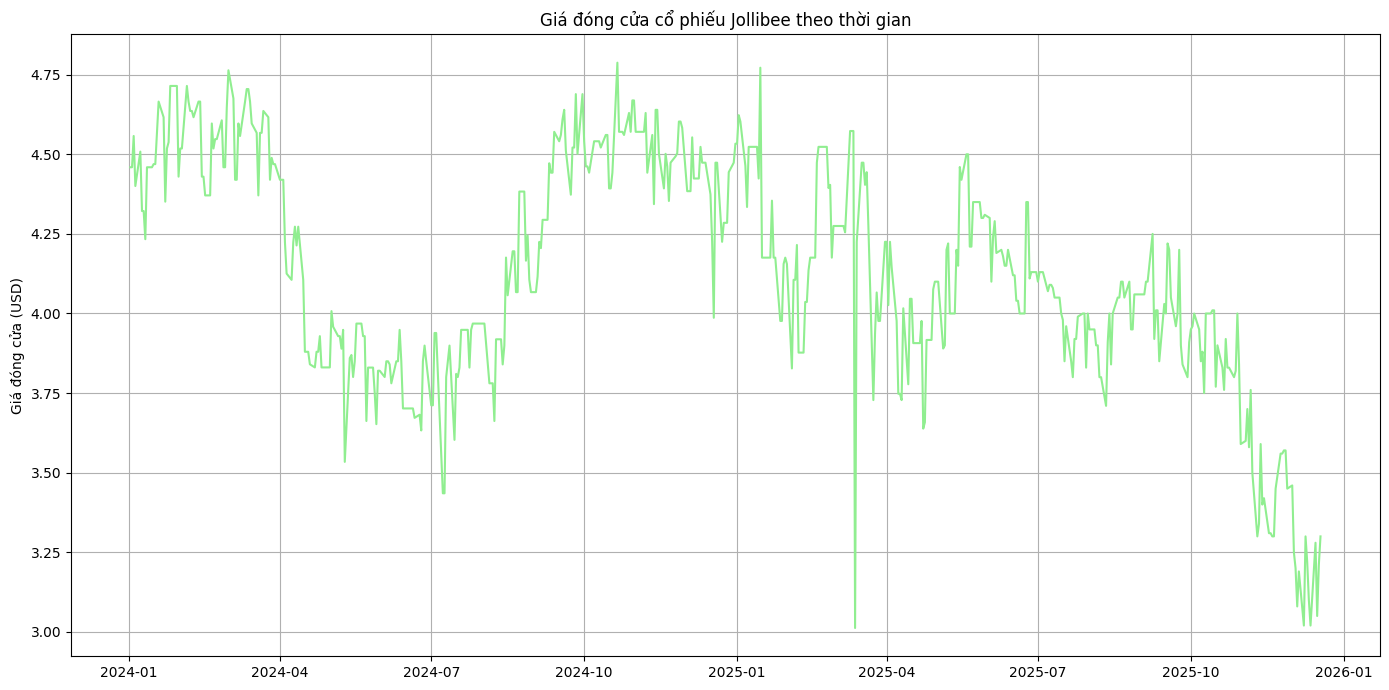

In [80]:
# Trực quan hóa dữ liệu giá đóng cửa
plt.figure(figsize=(14, 7))
plt.plot(clean_jollibee_stock.index, clean_jollibee_stock['Close'], label='Giá đóng cửa', color='lightgreen')
plt.title('Giá đóng cửa cổ phiếu Jollibee theo thời gian')
plt.xlabel('')
plt.ylabel('Giá đóng cửa (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [81]:
# Kiểm định tính dừng của dữ liệu
def adf_table(series, name):
    """
    Kiểm định tính dừng ADF cho chuỗi dữ liệu và trả về bảng kết quả.
    """
    result = adfuller(series.dropna())
    test_stat     = result[0]
    p_value       = result[1]
    lags_used     = result[2]
    n_obs         = result[3]
    critical_vals = result[4]
    table = pd.DataFrame({
        name: [
            test_stat,
            p_value,
            lags_used,
            n_obs,
            critical_vals['1%'],
            critical_vals['5%'],
            critical_vals['10%']
        ]
    }, index=[
        "ADF test statistic",
        "p-value",
        "Lags used",
        "Observations",
        "Critical value (1%)",
        "Critical value (5%)",
        "Critical value (10%)"
    ])
    return table

In [82]:
print("Kết quả kiểm định ADF cho giá đóng cửa cổ phiếu Jollibee:")
print(adf_table(clean_jollibee_stock['Close'], 'Close Price'))

Kết quả kiểm định ADF cho giá đóng cửa cổ phiếu Jollibee:
                      Close Price
ADF test statistic      -0.865191
p-value                  0.799219
Lags used                6.000000
Observations           506.000000
Critical value (1%)     -3.443340
Critical value (5%)     -2.867269
Critical value (10%)    -2.569821


=> Chuỗi không dừng và cần sử dụng sai phân

In [83]:
# Tạo sai phân
clean_jollibee_stock['Close_Diff'] = clean_jollibee_stock['Close'].diff()
clean_jollibee_stock = clean_jollibee_stock.dropna()
# Kiểm định ADF trên chuỗi sai phân
print("Kết quả kiểm định ADF cho chuỗi sai phân giá đóng cửa cổ phiếu Jollibee:")
print(adf_table(clean_jollibee_stock['Close_Diff'], 'Close Price Diff'))

Kết quả kiểm định ADF cho chuỗi sai phân giá đóng cửa cổ phiếu Jollibee:
                      Close Price Diff
ADF test statistic       -1.400867e+01
p-value                   3.747948e-26
Lags used                 5.000000e+00
Observations              5.060000e+02
Critical value (1%)      -3.443340e+00
Critical value (5%)      -2.867269e+00
Critical value (10%)     -2.569821e+00


=> chuỗi dừng

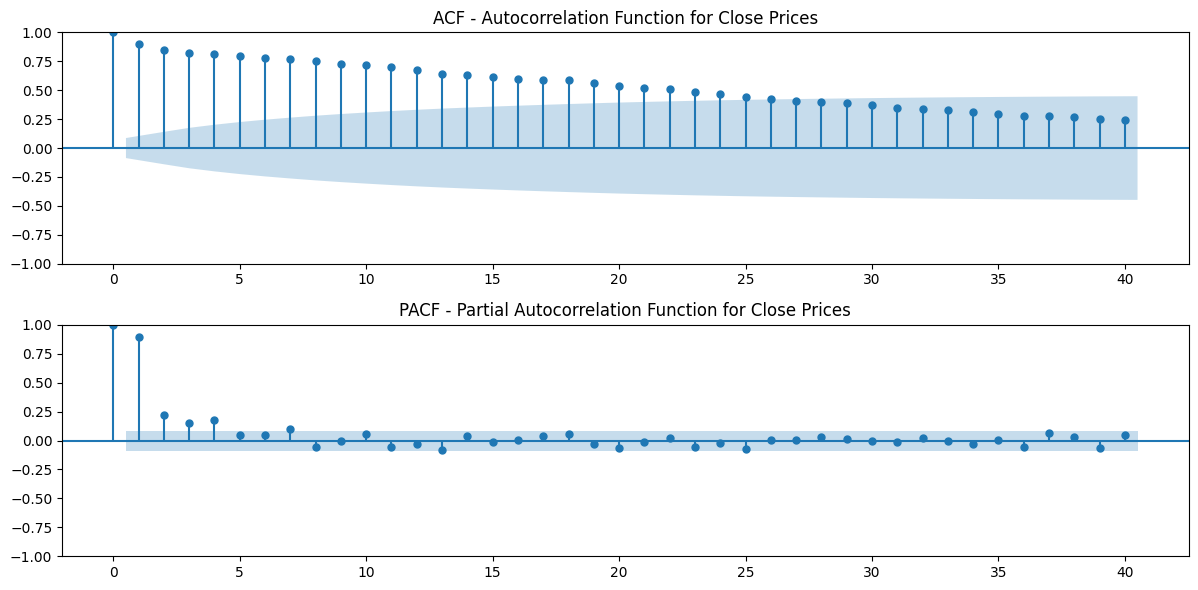

In [84]:
# Vẽ biểu đồ ACF và PACF cho giá đóng cửa
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plot_acf(clean_jollibee_stock['Close'], ax=plt.gca(), lags=40)
plt.title("ACF - Autocorrelation Function for Close Prices")

plt.subplot(2,1,2)
plot_pacf(clean_jollibee_stock['Close'], ax=plt.gca(), method='ywm', lags=40)
plt.title("PACF - Partial Autocorrelation Function for Close Prices")

plt.tight_layout()
plt.show()


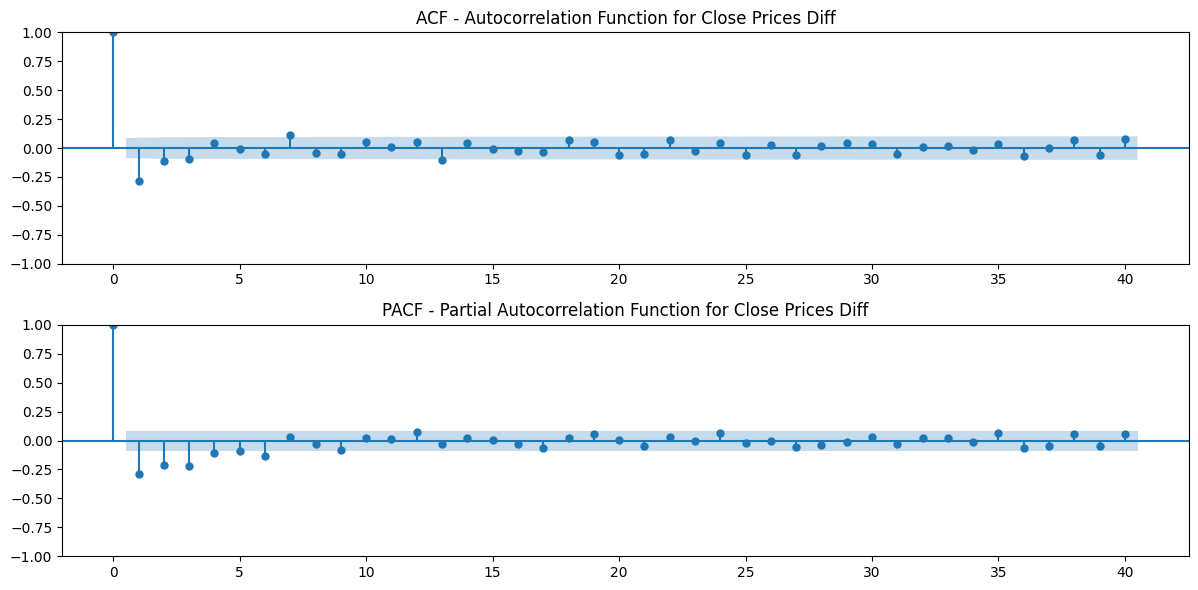

In [85]:
# Vẽ biểu đồ ACF và PACF cho chuỗi sai phân
plt.figure(figsize=(12,6))

plt.subplot(2,1,1)
plot_acf(clean_jollibee_stock['Close_Diff'], ax=plt.gca(), lags=40)
plt.title("ACF - Autocorrelation Function for Close Prices Diff")

plt.subplot(2,1,2)
plot_pacf(clean_jollibee_stock['Close_Diff'], ax=plt.gca(), method='ywm', lags=40)
plt.title("PACF - Partial Autocorrelation Function for Close Prices Diff")

plt.tight_layout()
plt.show()


# 5. Thử nghiệm các cấu hình mô hình ARIMA

In [86]:
list_p = list(range(0,7))
list_d = [1]
list_q = list(range(0,6))
model_dict = {}
for p in list_p:
    for d in list_d:
        for q in list_q:
            try:
                model = ARIMA(clean_jollibee_stock['Close'], order=(p,d,q))
                model_fit = model.fit()
                print(f'ARIMA({p},{d},{q}) - AIC:{model_fit.aic} BIC:{model_fit.bic}')
                model_dict[(p,d,q)] = (model_fit.aic, model_fit.bic)
            except Exception as e:
                print(f"ARIMA({p},{d},{q}) không thành công: {e}")
# Tìm bộ tham số (p,d,q) với AIC và BIC thấp nhất
best_aic_model = min(model_dict, key=lambda x: model_dict[x][0])
best_bic_model = min(model_dict, key=lambda x: model_dict[x][1])
print("Kết quả chọn mô hình ARIMA tốt nhất dựa trên AIC và BIC:")
print(f"Mô hình có AIC thấp nhất là {best_aic_model}:  AIC = {model_dict[best_aic_model][0]}")
print(f"Mô hình có BIC thấp nhất là {best_bic_model}:  BIC = {model_dict[best_bic_model][1]}")
p,d,q = best_bic_model

ARIMA(0,1,0) - AIC:-435.76332675922845 BIC:-431.52695716902474
ARIMA(0,1,1) - AIC:-517.3383750692384 BIC:-508.865635888831
ARIMA(0,1,2) - AIC:-535.4551300838989 BIC:-522.7460213132878
ARIMA(0,1,3) - AIC:-535.4445579259805 BIC:-518.4990795651656
ARIMA(0,1,4) - AIC:-536.567741563819 BIC:-515.3858936128005
ARIMA(0,1,5) - AIC:-534.603939988398 BIC:-509.18572244717575
ARIMA(1,1,0) - AIC:-478.12022729035465 BIC:-469.64748810994723
ARIMA(1,1,1) - AIC:-535.8206336742772 BIC:-523.1115249036661
ARIMA(1,1,2) - AIC:-534.5449000330323 BIC:-517.5994216722174
ARIMA(1,1,3) - AIC:-534.8069091600931 BIC:-513.6250612090746


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(1,1,4) - AIC:-534.9031870731222 BIC:-509.4849695319
ARIMA(1,1,5) - AIC:-533.3446900153665 BIC:-503.69010288394054
ARIMA(2,1,0) - AIC:-498.9755630324786 BIC:-486.26645426186747


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


ARIMA(2,1,1) - AIC:-534.9530876653557 BIC:-518.0076093045409
ARIMA(2,1,2) - AIC:-533.0531275096615 BIC:-511.871279558643
ARIMA(2,1,3) - AIC:-535.7434016921285 BIC:-510.32518415090624


...

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(6,1,3) - AIC:-534.7308425523009 BIC:-492.3671466502639


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA(6,1,4) - AIC:-535.2071869189483 BIC:-488.6071214267076
ARIMA(6,1,5) - AIC:-536.4098736298886 BIC:-485.57343854744414
Kết quả chọn mô hình ARIMA tốt nhất dựa trên AIC và BIC:
Mô hình có AIC thấp nhất là (3, 1, 3):  AIC = -540.173240390658
Mô hình có BIC thấp nhất là (1, 1, 1):  BIC = -523.1115249036661


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [87]:
model = auto_arima(
    clean_jollibee_stock['Close'],
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    d=None,
    seasonal=False,
    test='adf',
    information_criterion='bic',
    stepwise=False,
    enforce_stationarity=True,
    enforce_invertibility=True,
    suppress_warnings=True,
    trace=True
)

print("Bộ tham số model tốt nhất được chọn bởi auto_arima:")
print(model.summary())

 ARIMA(0,1,0)(0,0,0)[0] intercept   : BIC=-425.396, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : BIC=-503.361, Time=0.19 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : BIC=-517.684, Time=0.36 sec
 ARIMA(0,1,3)(0,0,0)[0] intercept   : BIC=-513.549, Time=1.15 sec
 ARIMA(0,1,4)(0,0,0)[0] intercept   : BIC=-510.296, Time=2.10 sec
 ARIMA(0,1,5)(0,0,0)[0] intercept   : BIC=-504.081, Time=1.14 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : BIC=-463.617, Time=0.19 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : BIC=-518.152, Time=0.62 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : BIC=-512.616, Time=0.68 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : BIC=-508.662, Time=0.84 sec
 ARIMA(1,1,4)(0,0,0)[0] intercept   : BIC=-504.081, Time=1.36 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : BIC=-480.359, Time=0.20 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : BIC=-513.001, Time=0.68 sec
 ARIMA(2,1,2)(0,0,0)[0] intercept   : BIC=-506.919, Time=0.49 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : BIC=-505.235, Time=1.16 sec
 ARIMA(3,1

## Thử nghiệm ARIMA(1,1,1)

In [88]:
arima = ARIMA(clean_jollibee_stock['Close'], order=(p,d,q))
arima_fit = arima.fit()
print(f"Tóm tắt mô hình ARIMA({p},{d},{q}):")
print(arima_fit.summary())

Tóm tắt mô hình ARIMA(1,1,1):
                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  512
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 270.910
Date:                Wed, 24 Dec 2025   AIC                           -535.821
Time:                        17:47:04   BIC                           -523.112
Sample:                    01-03-2024   HQIC                          -530.838
                         - 12-18-2025                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3082      0.051      6.082      0.000       0.209       0.408
ma.L1         -0.7608      0.050    -15.333      0.000      -0.858      -0.664
sigma2         0.0203 

In [89]:
# Hàm kiểm tra mô hình ARIMA có ổn định không
def check_arima_stability(model_fit):
    stable = True

    # kiểm tra AR roots
    if hasattr(model_fit, "arroots"):
        if np.any(np.abs(model_fit.arroots) <= 1):
            stable = False

    # kiểm tra MA roots
    if hasattr(model_fit, "maroots"):
        if np.any(np.abs(model_fit.maroots) <= 1):
            stable = False

    return stable
is_stable = check_arima_stability(arima_fit)
print(f"Mô hình ARIMA({p},{d},{q}) có ổn định không? {'Đúng' if is_stable else 'Sai'}")

Mô hình ARIMA(1,1,1) có ổn định không? Đúng


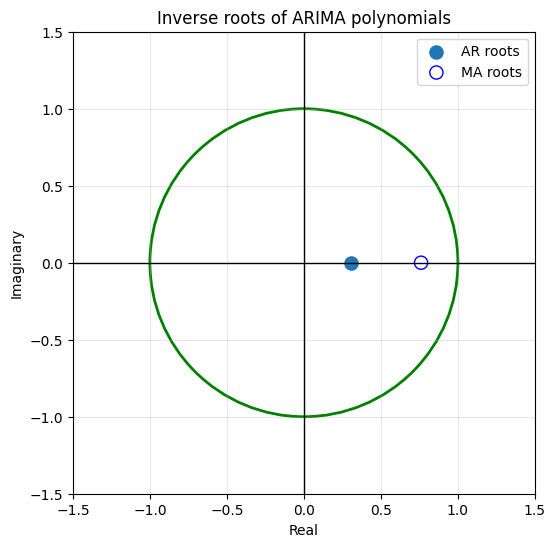

In [90]:
# lấy nghiệm AR & MA từ mô hình đã fit
ar_roots = arima_fit.arroots
ma_roots = arima_fit.maroots

# nghịch đảo roots
inv_ar = 1 / ar_roots
inv_ma = 1 / ma_roots

# tạo plot giống Stata
plt.figure(figsize=(6,6))

ax = plt.gca()

# vẽ vòng tròn đơn vị đúng chuẩn stats/Stata
circle = plt.Circle((0,0), 1, edgecolor='green', lw=2, fill=False)
ax.add_patch(circle)

# vẽ nghiệm nghịch đảo
plt.scatter(inv_ar.real, inv_ar.imag, label="AR roots", s=90)
plt.scatter(inv_ma.real, inv_ma.imag, label="MA roots", s=90, facecolors='none', edgecolors='blue')

# cài đặt trục giống Stata
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# scale tương đương Stata (±1.5 là phù hợp)
plt.xlim(-1.5,1.5)
plt.ylim(-1.5,1.5)

plt.title("Inverse roots of ARIMA polynomials")
plt.xlabel("Real")
plt.ylabel("Imaginary")

plt.gca().set_aspect('equal', adjustable='box')   # giữ tròn đúng tỷ lệ
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [91]:
# Kiểm định phần dư của mô hình ARIMA(1,1,1)
residuals = arima_fit.resid
# Kiểm định tính dừng ADF cho phần dư
print(f"Kết quả kiểm định ADF cho phần dư của mô hình ARIMA({p},{d},{q}):")
print(adf_table(residuals, f'ARIMA({p},{d},{q}) Residuals'))
# Kiểm định Portmanteau (Ljung-Box) cho phần dư
ljung_box_result = acorr_ljungbox(residuals, lags=[10], return_df=True)
print(f"Kết quả kiểm định Ljung-Box cho phần dư của mô hình ARIMA({p},{d},{q}):")
print(ljung_box_result)

Kết quả kiểm định ADF cho phần dư của mô hình ARIMA(1,1,1):
                      ARIMA(1,1,1) Residuals
ADF test statistic                -37.900733
p-value                             0.000000
Lags used                           0.000000
Observations                      511.000000
Critical value (1%)                -3.443212
Critical value (5%)                -2.867213
Critical value (10%)               -2.569791
Kết quả kiểm định Ljung-Box cho phần dư của mô hình ARIMA(1,1,1):
     lb_stat  lb_pvalue
10  3.171831   0.977086


=> Chuỗi phần dư là chuỗi dừng và không có tự tương quan

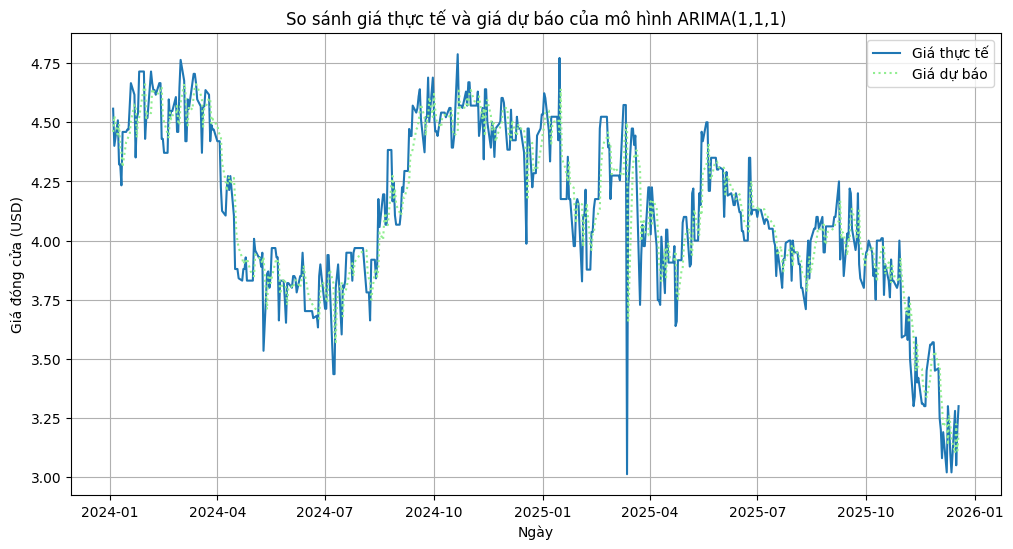

In [92]:
# Dự báo toàn bộ chuỗi giá đóng cửa để xem mức độ khớp của mô hình
forecast = arima_fit.predict(start=0, end=len(clean_jollibee_stock)-1)
# So sánh giá trị dự báo với giá trị thực tế
plt.figure(figsize=(12, 6))
plt.plot(clean_jollibee_stock.iloc[1:].index, clean_jollibee_stock['Close'].iloc[1:], label='Giá thực tế')
plt.plot(clean_jollibee_stock.iloc[1:].index, forecast.iloc[1:], label='Giá dự báo', color = 'lightgreen', linestyle='dotted')
plt.title(f'So sánh giá thực tế và giá dự báo của mô hình ARIMA({p},{d},{q})')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa (USD)')
plt.legend()
plt.grid(True)
plt.show()

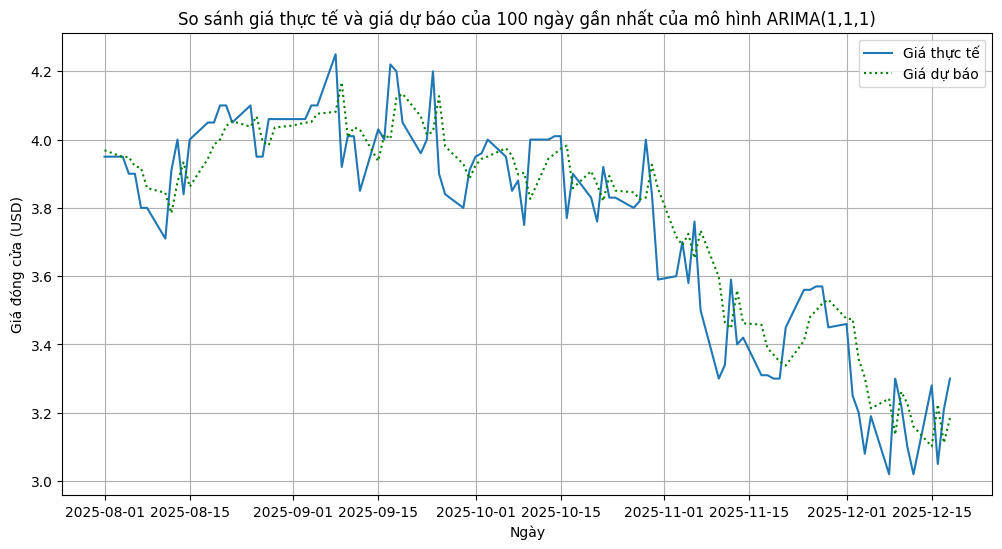

In [93]:
# Tách nhỏ 1 đoạn dữ liệu con để so sánh kĩ hơn
n_closest_days = 100
actual_last = clean_jollibee_stock['Close'].iloc[-n_closest_days:]
pred_last = forecast[-n_closest_days:]
# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(actual_last.index, actual_last, label=f'Giá thực tế')
plt.plot(actual_last.index, pred_last, label='Giá dự báo', color = 'green', linestyle='dotted')
plt.title(f'So sánh giá thực tế và giá dự báo của {n_closest_days} ngày gần nhất của mô hình ARIMA({p},{d},{q})')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa (USD)')
plt.legend()
plt.grid(True)
plt.show()

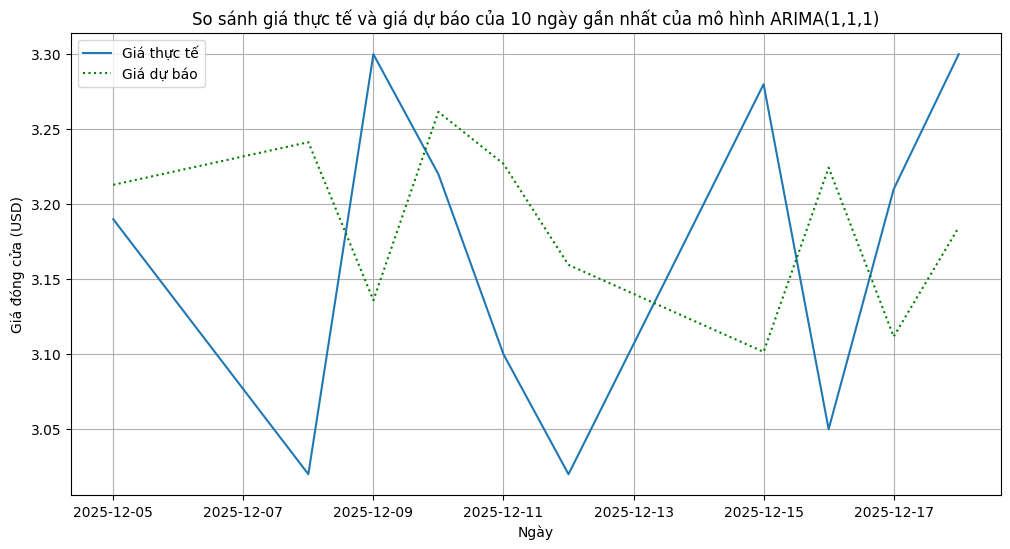

In [94]:
# Tách nhỏ 1 đoạn dữ liệu con để so sánh kĩ hơn
n_closest_days = 10
actual_last = clean_jollibee_stock['Close'].iloc[-n_closest_days:]
pred_last = forecast[-n_closest_days:]
# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(actual_last.index, actual_last, label=f'Giá thực tế')
plt.plot(actual_last.index, pred_last, label='Giá dự báo', color = 'green', linestyle='dotted')
plt.title(f'So sánh giá thực tế và giá dự báo của {n_closest_days} ngày gần nhất của mô hình ARIMA({p},{d},{q})')
plt.xlabel('Ngày')
plt.ylabel('Giá đóng cửa (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [95]:
y_true = clean_jollibee_stock['Close']

y_pred = forecast.values
# Đảm bảo y_true và y_pred có cùng độ dài
y_pred = y_pred[:len(y_true)]

# tính các chỉ số
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

MAE: 0.10608867180920895
MSE: 0.059069815209197366
RMSE: 0.2430428258747774


# 6. Huấn luyện model XGBoost dựa trên phần dư để tạo kiến trúc mô hình lai

In [96]:
clean_jollibee_stock['ARIMA_pred'] = arima_fit.predict(start=0, end=len(clean_jollibee_stock)-1)
clean_jollibee_stock.head()

,Close,Close_Diff,ARIMA_pred
Date,,,
2024-01-03,4.459289,0.000000,0.000000
2024-01-04,4.557511,0.098222,4.459289
2024-01-05,4.400356,-0.157155,4.526851
2024-01-08,4.508400,0.108044,4.438862
2024-01-09,4.321778,-0.186622,4.491600


In [97]:
# Xóa dòng đầu, do dòng đó không có dữ liệu quá khứ cho ARIMA dự đoán nên kết quả dự đoán=0
clean_jollibee_stock = clean_jollibee_stock.iloc[1:]
clean_jollibee_stock.head()

,Close,Close_Diff,ARIMA_pred
Date,,,
2024-01-04,4.557511,0.098222,4.459289
2024-01-05,4.400356,-0.157155,4.526851
2024-01-08,4.508400,0.108044,4.438862
2024-01-09,4.321778,-0.186622,4.491600
2024-01-10,4.321778,0.000000,4.389611


In [98]:
# Tính phần sai lệch giữa dự đoán của ARIMA và giá trị thực
clean_jollibee_stock['Res'] = clean_jollibee_stock['Close'] - clean_jollibee_stock['ARIMA_pred']
clean_jollibee_stock.head()

,Close,Close_Diff,ARIMA_pred,Res
Date,,,,
2024-01-04,4.557511,0.098222,4.459289,0.098222
2024-01-05,4.400356,-0.157155,4.526851,-0.126496
2024-01-08,4.508400,0.108044,4.438862,0.069538
2024-01-09,4.321778,-0.186622,4.491600,-0.169822
2024-01-10,4.321778,0.000000,4.389611,-0.067833


In [99]:
clean_jollibee_stock.tail()

,Close,Close_Diff,ARIMA_pred,Res
Date,,,,
2025-12-12,3.02,-0.08,3.159586,-0.139586
2025-12-15,3.28,0.26,3.101534,0.178466
2025-12-16,3.05,-0.23,3.224371,-0.174371
2025-12-17,3.21,0.16,3.111761,0.098239
2025-12-18,3.30,0.09,3.184581,0.115419


In [100]:
# Tạo các features từ dự báo của ARIMA
def create_features_from_arima(arima_preds, residuals=None, window_size=5):
    """
    Tạo X từ chuỗi dự báo của ARIMA (arima_preds).
    Tạo y từ chuỗi sai số (residuals)
    """
    X, y = [], []

    # Đảm bảo input là dạng list hoặc array
    vals = arima_preds.values if isinstance(arima_preds, pd.Series) else arima_preds
    res_vals = residuals.values if isinstance(residuals, pd.Series) and residuals is not None else residuals
    # Cần đủ dữ liệu cho window_size
    if len(vals) <= window_size:
        return np.array([]), np.array([])

    for i in range(len(vals) - window_size):
        # Lấy cửa sổ các giá trị dự báo trước đó
        window = vals[i : i+window_size]

        # Giá trị dự báo hiện tại (tại thời điểm T)
        # Đây là feature quan trọng nhất: "Với mức giá dự báo này, sai số thường là bao nhiêu?"
        current_pred = vals[i+window_size]

        features = []
        features.append(current_pred)       # Giá trị dự báo hiện tại
        features.append(np.mean(window))    # Trung bình các dự báo gần đây
        features.append(np.std(window))     # Độ biến động của các dự báo gần đây
        features.append(window[-1] - window[0]) # Xu hướng (Trend) của dự báo

        X.append(features)

        # Tạo y
        if res_vals is not None:
            y.append(res_vals[i+window_size])
    return np.array(X), np.array(y) if res_vals is not None else None

def find_best_window_with_plot(arima_preds, residuals, candidates):
    rmse_scores = []
    valid_candidates = []
    for size in candidates:
        # 1. Tạo dữ liệu với window_size này
        X_curr, y_curr = create_features_from_arima(arima_preds, residuals, window_size=size)

        # Bỏ qua nếu không đủ dữ liệu để train
        if len(X_curr) < 50:
            continue

        # 2. Chia Train/Val (80% / 20%) - Chia theo thời gian
        split = int(len(X_curr) * 0.8)
        X_tr, X_val = X_curr[:split], X_curr[split:]
        y_tr, y_val = y_curr[:split], y_curr[split:]

        # 3. Train XGBoost nhanh (Default params)
        model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=50, max_depth=3, verbosity=0)
        model.fit(X_tr, y_tr)

        # 4. Đánh giá
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        rmse_scores.append(rmse)
        valid_candidates.append(size)

    # --- TÌM KẾT QUẢ TỐT NHẤT ---
    best_idx = np.argmin(rmse_scores)
    best_size = valid_candidates[best_idx]
    best_rmse = rmse_scores[best_idx]

    print(f"Window Size tốt nhất là {best_size} (RMSE thấp nhất: {best_rmse:.5f})")

    # --- VẼ BIỂU ĐỒ ---
    plt.figure(figsize=(12, 6))

    # Vẽ đường biểu diễn RMSE
    plt.plot(valid_candidates, rmse_scores, marker='o', linestyle='-', color='royalblue', label='RMSE Score')

    # Đánh dấu điểm tốt nhất
    plt.axvline(best_size, color='red', linestyle='--', label=f'Best Window: {best_size}')
    plt.scatter(best_size, best_rmse, color='red', s=100, zorder=5)

    # Trang trí
    plt.title('Tương quan giữa Window Size và Sai số (RMSE)', fontsize=14)
    plt.xlabel('Window Size (Số ngày quan sát)', fontsize=12)
    plt.ylabel('RMSE (Sai số dự báo)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Hiển thị giá trị tại điểm thấp nhất
    plt.annotate(f'RMSE: {best_rmse:.5f}',
                 xy=(best_size, best_rmse),
                 xytext=(best_size+2, best_rmse + (max(rmse_scores)-min(rmse_scores))*0.1)
    )

    plt.show()

    return best_size

Window Size tốt nhất là 4 (RMSE thấp nhất: 0.13709)


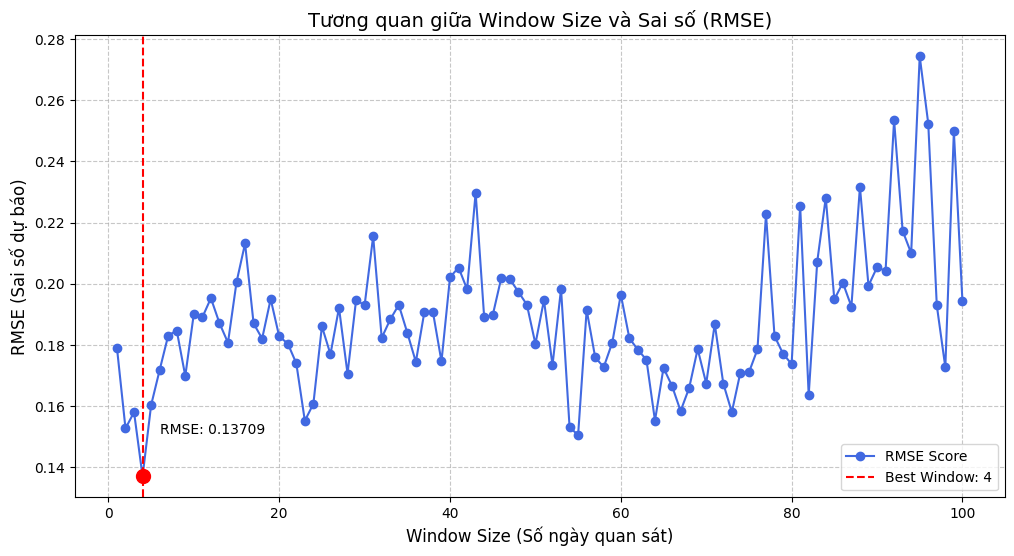

Đã tạo bộ dữ liệu X cuối cùng với shape: (507, 4)


In [101]:
candidate_sizes = list(range(1, 101))

best_window_size = find_best_window_with_plot(
    clean_jollibee_stock['ARIMA_pred'],
    clean_jollibee_stock['Res'],
    candidate_sizes
)
# Cập nhật lại dữ liệu train cuối cùng với size tốt nhất
X, y = create_features_from_arima(clean_jollibee_stock['ARIMA_pred'], clean_jollibee_stock['Res'], best_window_size)
print(f"Đã tạo bộ dữ liệu X cuối cùng với shape: {X.shape}")

In [102]:
xgb_model = xgb.XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1)

# Thiết lập tham số (Có thể dùng RandomizedSearchCV như bài trước nếu muốn kỹ hơn)
params = {
    "n_estimators": 500,
    "learning_rate": 0.05,
    "max_depth": 5,
    "subsample": 0.8,
    "colsample_bytree": 0.8
}

xgb_reg = xgb.XGBRegressor(**params)
xgb_reg.fit(X, y)
print("Đã huấn luyện xong XGBoost")

Đã huấn luyện xong XGBoost


# 7. Dự báo

In [103]:
def forecast_next_day(arima_results, xgb_model, history_data, recent_arima_preds, window_size):
    """
    Args:
        history_data: Dữ liệu giá thực tế
        recent_arima_preds: List chứa các giá trị ARIMA dự báo gần đây
    """
    # 1. ARIMA dự báo bước tiếp theo (Linear)
    # Update model với dữ liệu lịch sử mới nhất
    new_arima = arima_results.apply(history_data)
    arima_pred_val = new_arima.forecast(steps=1).iloc[0]

    # 2. Tạo Feature cho XGBoost
    # Lấy cửa sổ các dự báo gần nhất + dự báo vừa tính xong
    # Cần window_size điểm dữ liệu cũ để tính mean/std cho điểm hiện tại
    current_window_preds = recent_arima_preds[-window_size:] + [arima_pred_val]

    # Tính toán thủ công các feature (giống hệt hàm create_features_from_arima)
    # Window trượt là đoạn ngay trước điểm dự báo
    window_calc = current_window_preds[:-1] # Lấy window_size phần tử trước đó
    current_val = current_window_preds[-1]  # Giá trị ARIMA hiện tại

    feat_mean = np.mean(window_calc)
    feat_std = np.std(window_calc)
    feat_trend = window_calc[-1] - window_calc[0]

    # X = [Current_Pred, Mean, Std, Trend]
    xgb_input = np.array([[current_val, feat_mean, feat_std, feat_trend]])

    # 3. XGBoost dự báo sai số
    xgb_error_pred = xgb_model.predict(xgb_input)[0]

    # 4. Tổng hợp
    final_pred = arima_pred_val + xgb_error_pred

    return final_pred, arima_pred_val

In [104]:
def forecast_multi_days(n_days, arima_fit, xgb_reg, current_data, best_window_size):

    # Khởi tạo lịch sử giá (để ARIMA update)
    history_prices = current_data.copy()

    # Khởi tạo lịch sử DỰ BÁO của ARIMA (để tạo feature cho XGBoost)
    # Lấy dự báo in-sample đoạn cuối để làm mồi
    recent_arima_preds = list(arima_fit.fittedvalues[-best_window_size:].values)

    results = []

    print(f"--- Bắt đầu dự báo {n_days} ngày (X=ARIMA_Pred) ---")

    for i in range(n_days):
        final, arima_val = forecast_next_day(
            arima_fit,
            xgb_reg,
            history_prices,
            recent_arima_preds,
            best_window_size
        )

        # Xác định ngày
        last_date = history_prices.index[-1]
        next_date = last_date + BusinessDay(1)

        # Lưu kết quả
        results.append({'Date': next_date, 'Final_Forecast': final})

        # Cập nhật cho vòng lặp sau:
        # 1. Thêm giá dự báo cuối cùng vào lịch sử giá (Recursive)
        new_row = pd.Series([final], index=[next_date])
        history_prices = pd.concat([history_prices, new_row])

        # 2. Thêm giá ARIMA dự báo vào danh sách dự báo (để tính mean/std vòng sau)
        recent_arima_preds.append(arima_val)

    return pd.DataFrame(results).set_index('Date')

Đã tính xong In-sample fit cho 508 điểm dữ liệu.
--- Bắt đầu dự báo 30 ngày (X=ARIMA_Pred) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dat

            Final_Forecast
Date                      
2025-12-19        3.200644
2025-12-22        3.289821
2025-12-23        3.247366
2025-12-24        3.150263
2025-12-25        3.273670
2025-12-26        3.160101
2025-12-29        3.223658
2025-12-30        3.255383
2025-12-31        3.203359
2026-01-01        3.184884
2026-01-02        3.274049
2026-01-05        3.248862
2026-01-06        3.262237
2026-01-07        3.280053
2026-01-08        3.273848
2026-01-09        3.353024
2026-01-12        3.385566
2026-01-13        3.353435
2026-01-14        3.342346
2026-01-15        3.346939
2026-01-16        3.455158
2026-01-19        3.513958
2026-01-20        3.477726
2026-01-21        3.471268
2026-01-22        3.472446
2026-01-23        3.393705
2026-01-26        3.465078
2026-01-27        3.401970
2026-01-28        3.490729
2026-01-29        3.485321


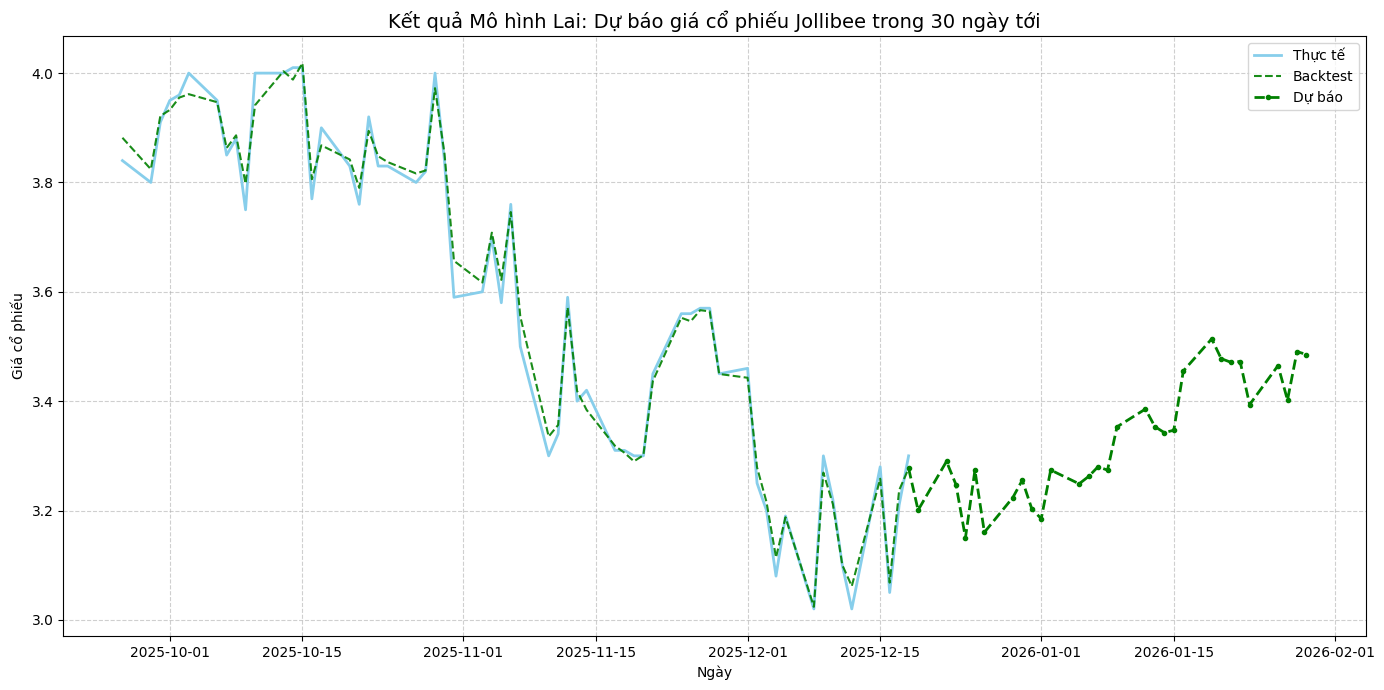

In [105]:
# Lấy giá trị dự báo tuyến tính của ARIMA
arima_linear_insample = arima_fit.fittedvalues

# Tính Residuals thực tế
residuals_insample = clean_jollibee_stock['Close'] - arima_linear_insample

# Tạo Features cho XGBoost từ ARIMA In-sample
X_insample, _ = create_features_from_arima(arima_linear_insample, residuals_insample, best_window_size)

# XGBoost dự đoán sai số
if len(X_insample) > 0:
    xgb_correction_insample = xgb_reg.predict(X_insample)

    # Tổng hợp Hybrid Fit = ARIMA Linear + XGB Correction
    arima_aligned = arima_linear_insample.iloc[best_window_size:]
    hybrid_insample_values = arima_aligned.values + xgb_correction_insample
    # Tạo Series kết quả
    hybrid_insample_series = pd.Series(hybrid_insample_values, index=arima_aligned.index)
    print(f"Đã tính xong In-sample fit cho {len(hybrid_insample_series)} điểm dữ liệu.")
else:
    print("Lỗi: Không đủ dữ liệu để tính In-sample fit.")
    hybrid_insample_series = pd.Series()

days_to_predict = 30
df_future = forecast_multi_days(
    days_to_predict,
    arima_fit,
    xgb_reg,
    clean_jollibee_stock['Close'],
    best_window_size
)

print(df_future)

plt.figure(figsize=(14, 7))

# 1. Vẽ dữ liệu thực tế
plot_length = 60
last_real = clean_jollibee_stock['Close'].iloc[-plot_length:]
plt.plot(last_real.index, last_real.values,
         label='Thực tế', color='skyblue', linewidth=2)

# 2. Vẽ dữ liệu in-sample fit
common_idx = last_real.index.intersection(hybrid_insample_series.index)
plot_insample = hybrid_insample_series.loc[common_idx]

plt.plot(plot_insample.index, plot_insample.values,
         label='Backtest',
         color='green',
         linestyle='--',
         linewidth=1.5, alpha=0.9)

# 3. Vẽ dữ liệu dự báo
# Lấy điểm cuối cùng của đường In-sample
last_model_date = hybrid_insample_series.index[-1]
last_model_val = hybrid_insample_series.iloc[-1]

# Tạo điểm neo
connector = pd.DataFrame({'Final_Forecast': [last_model_val]}, index=[last_model_date])

# Gộp với dự báo tương lai
plot_future_connected = pd.concat([connector, df_future[['Final_Forecast']]])

plt.plot(plot_future_connected.index, plot_future_connected['Final_Forecast'],
         label='Dự báo',
         color='green',
         linestyle='--',
         marker='.',
         linewidth=2)

plt.title(f'Kết quả Mô hình Lai: Dự báo giá cổ phiếu Jollibee trong {days_to_predict} ngày tới', fontsize=14)
plt.xlabel('Ngày')
plt.ylabel('Giá cổ phiếu')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Đã tính xong In-sample fit cho 508 điểm dữ liệu.
--- Bắt đầu dự báo 10 ngày (X=ARIMA_Pred) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency B will be used.
  self._init_dates(dat

            Final_Forecast
Date                      
2025-12-19        3.200644
2025-12-22        3.289821
2025-12-23        3.247366
2025-12-24        3.150263
2025-12-25        3.273670
2025-12-26        3.160101
2025-12-29        3.223658
2025-12-30        3.255383
2025-12-31        3.203359
2026-01-01        3.184884


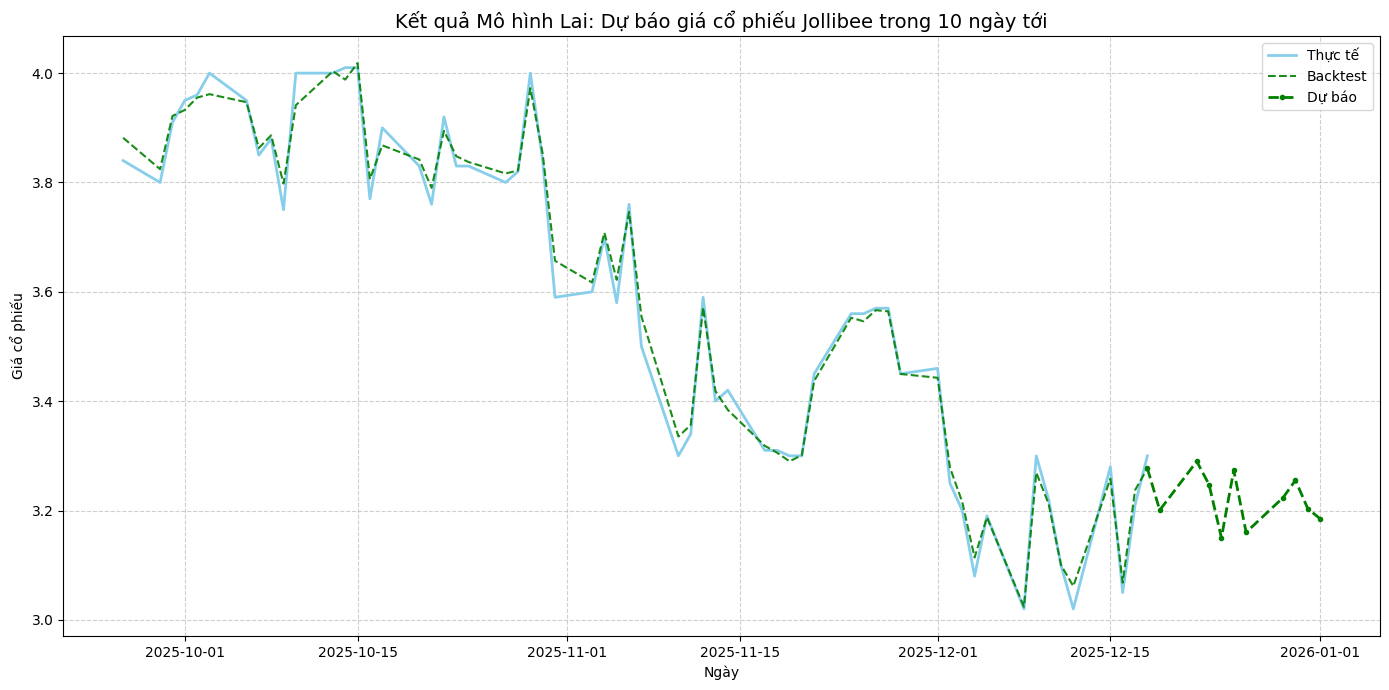

In [106]:
# Lấy giá trị dự báo tuyến tính của ARIMA
arima_linear_insample = arima_fit.fittedvalues

# Tính Residuals thực tế
residuals_insample = clean_jollibee_stock['Close'] - arima_linear_insample

# Tạo Features cho XGBoost từ ARIMA In-sample
X_insample, _ = create_features_from_arima(arima_linear_insample, residuals_insample, best_window_size)

# XGBoost dự đoán sai số
if len(X_insample) > 0:
    xgb_correction_insample = xgb_reg.predict(X_insample)

    # Tổng hợp Hybrid Fit = ARIMA Linear + XGB Correction
    arima_aligned = arima_linear_insample.iloc[best_window_size:]
    hybrid_insample_values = arima_aligned.values + xgb_correction_insample
    # Tạo Series kết quả
    hybrid_insample_series = pd.Series(hybrid_insample_values, index=arima_aligned.index)
    print(f"Đã tính xong In-sample fit cho {len(hybrid_insample_series)} điểm dữ liệu.")
else:
    print("Lỗi: Không đủ dữ liệu để tính In-sample fit.")
    hybrid_insample_series = pd.Series()

days_to_predict = 10
df_future = forecast_multi_days(
    days_to_predict,
    arima_fit,
    xgb_reg,
    clean_jollibee_stock['Close'],
    best_window_size
)

print(df_future)

plt.figure(figsize=(14, 7))

# 1. Vẽ dữ liệu thực tế
plot_length = 60
last_real = clean_jollibee_stock['Close'].iloc[-plot_length:]
plt.plot(last_real.index, last_real.values,
         label='Thực tế', color='skyblue', linewidth=2)

# 2. Vẽ dữ liệu in-sample fit
common_idx = last_real.index.intersection(hybrid_insample_series.index)
plot_insample = hybrid_insample_series.loc[common_idx]

plt.plot(plot_insample.index, plot_insample.values,
         label='Backtest',
         color='green',
         linestyle='--',
         linewidth=1.5, alpha=0.9)

# 3. Vẽ dữ liệu dự báo
# Lấy điểm cuối cùng của đường In-sample
last_model_date = hybrid_insample_series.index[-1]
last_model_val = hybrid_insample_series.iloc[-1]

# Tạo điểm neo
connector = pd.DataFrame({'Final_Forecast': [last_model_val]}, index=[last_model_date])

# Gộp với dự báo tương lai
plot_future_connected = pd.concat([connector, df_future[['Final_Forecast']]])

plt.plot(plot_future_connected.index, plot_future_connected['Final_Forecast'],
         label='Dự báo',
         color='green',
         linestyle='--',
         marker='.',
         linewidth=2)

plt.title(f'Kết quả Mô hình Lai: Dự báo giá cổ phiếu Jollibee trong {days_to_predict} ngày tới', fontsize=14)
plt.xlabel('Ngày')
plt.ylabel('Giá cổ phiếu')
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [107]:
# Đánh giá mô hình lai qua MAE, MSE, RMSE
common_index = clean_jollibee_stock['Close'].index.intersection(hybrid_insample_series.index)
y_true = clean_jollibee_stock['Close'].loc[common_index]
y_pred = hybrid_insample_series.loc[common_index]
# Tính toán các chỉ số
mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
# Tính thêm MAPE
mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
# Hiển thị kết quả
print("-" * 30)
print("Kết quả đánh giá mô hình lai:")
print(f"1. MAE:  {mae:.4f}")
print(f"2. MSE:   {mse:.4f}")
print(f"3. RMSE: {rmse:.4f}")
print(f"4. MAPE:  {mape:.2f}%")

# Nhận xét nhanh
price_range = y_true.max() - y_true.min()
print(f"Biên độ dao động giá thực tế: {price_range:.2f}")
if rmse < price_range * 0.1:
    print("=> Đánh giá: Mô hình khớp tốt (RMSE nhỏ hơn 10% biên độ giá).")
else:
    print("=> Đánh giá: Mô hình cần cải thiện thêm.")

------------------------------
Kết quả đánh giá mô hình lai:
1. MAE:  0.0208
2. MSE:   0.0008
3. RMSE: 0.0279
4. MAPE:  0.51%
Biên độ dao động giá thực tế: 1.78
=> Đánh giá: Mô hình khớp tốt (RMSE nhỏ hơn 10% biên độ giá).


Bảng so sánh kết quả:
                        RMSE       MAE  MAPE (%)
Model                                           
ARIMA (Thuần)       0.142586  0.097567  2.434317
Hybrid (ARIMA+XGB)  0.027885  0.020778  0.510407
kết luận: Mô hình Hybrid đã giảm sai số RMSE được: 80.44%


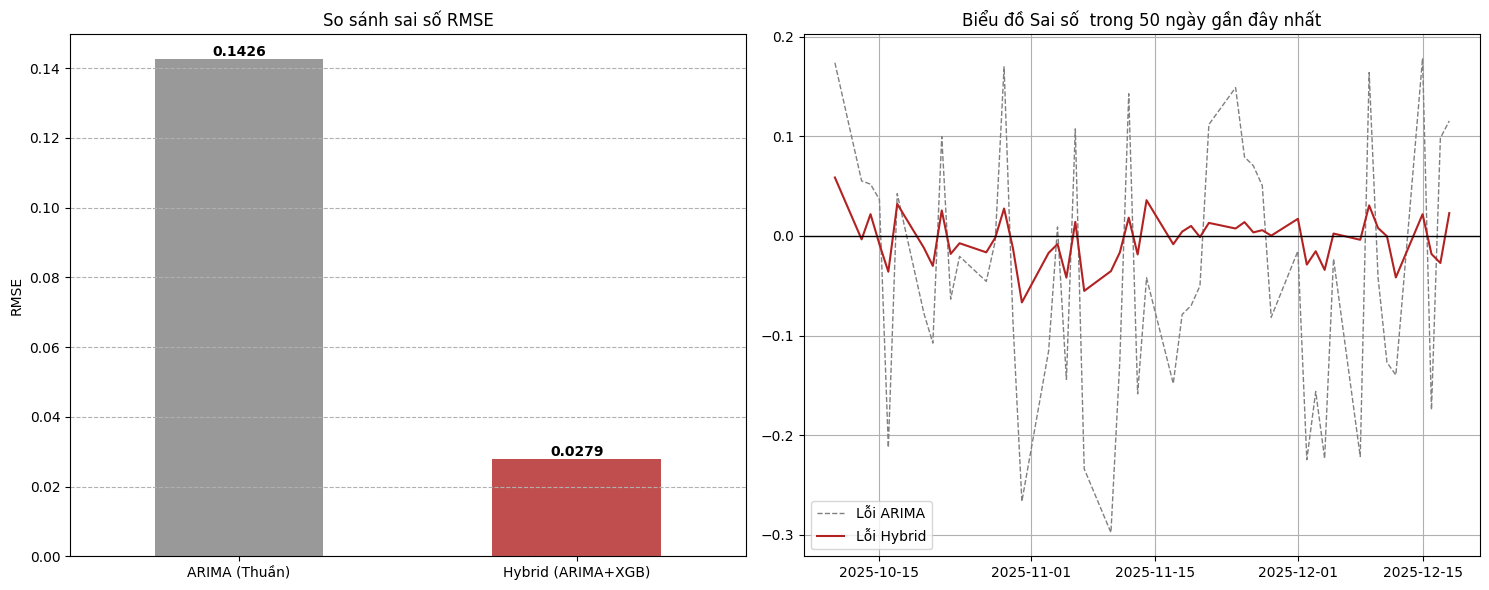

In [108]:
# So sánh hiệu suất của mô hình ARIMA thuần và Mô hình lai
# Lấy cùng một khoảng thời gian
common_index = hybrid_insample_series.index
# Lấy dữ liệu thực tế tại các ngày chung
y_true = clean_jollibee_stock['Close'].loc[common_index]
# Lấy dự báo của mô hình ARIMA gốc
y_arima = arima_fit.fittedvalues.loc[common_index]
# Lấy dự báo của mô hình lai
y_hybrid = hybrid_insample_series.loc[common_index]

def get_metrics(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape
    }

# Tính toán cho cả 2 mô hình
metrics_arima = get_metrics(y_true, y_arima, 'ARIMA (Thuần)')
metrics_hybrid = get_metrics(y_true, y_hybrid, 'Hybrid (ARIMA+XGB)')

comparison_df = pd.DataFrame([metrics_arima, metrics_hybrid])
comparison_df.set_index('Model', inplace=True)

# Tính độ cải thiện
arima_rmse = comparison_df.loc['ARIMA (Thuần)', 'RMSE']
hybrid_rmse = comparison_df.loc['Hybrid (ARIMA+XGB)', 'RMSE']
improvement = (arima_rmse - hybrid_rmse) / arima_rmse * 100

print("Bảng so sánh kết quả:")
print(comparison_df)
print(f"kết luận: Mô hình Hybrid đã giảm sai số RMSE được: {improvement:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
# So sánh RMSE (Cột)
comparison_df['RMSE'].plot(kind='bar', ax=axes[0], color=['gray', 'firebrick'], alpha=0.8, rot=0)
axes[0].set_title('So sánh sai số RMSE')
axes[0].set_ylabel('RMSE')
axes[0].grid(axis='y', linestyle='--')
axes[0].set_xlabel('')
for i, v in enumerate(comparison_df['RMSE']):
    axes[0].text(i, v + 0.001, f"{v:.4f}", ha='center', fontweight='bold')

# So sánh Residuals (Phần dư) trên 50 ngày cuối
last_n = 50
res_arima = y_true.iloc[-last_n:] - y_arima.iloc[-last_n:]
res_hybrid = y_true.iloc[-last_n:] - y_hybrid.iloc[-last_n:]

axes[1].plot(res_arima.index, res_arima, label='Lỗi ARIMA', color='gray', linestyle='--', linewidth=1)
axes[1].plot(res_hybrid.index, res_hybrid, label='Lỗi Hybrid', color='firebrick', linewidth=1.5)
axes[1].axhline(0, color='black', linewidth=1) # Trục 0 chuẩn
axes[1].set_title(f'Biểu đồ Sai số  trong {last_n} ngày gần đây nhất')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()